# Alternans and spiral breakup

Cardiac tissue must recover after each excitation before it can support another action potential.
The duration of the next action potential depends on the time available for recovery. This
relationship, called **action potential duration (APD) restitution**, helps explain why rapid
pacing can destabilize an otherwise regular rhythm.

**Alternans** is a beat-to-beat alternation between long and short action potentials. In tissue,
these variations can disrupt wave propagation and contribute to **spiral breakup**, in which a
rotating excitation wave fragments into additional waves.

This tutorial explores these ideas with the **ten Tusscher–Panfilov 2006 (TP06)** human ventricular
cell model. It introduces four restitution settings, compares single-cell restitution curves,
and follows spiral-wave activity in a two-dimensional sheet of tissue. The examples are based on
[ten Tusscher and Panfilov (2006)](https://doi.org/10.1152/ajpheart.00109.2006).

## 1. Restitution settings

The four parameter sets are labeled **0.7, 1.1, 1.4, and 1.8**, following Table 2 of the paper.
These labels describe the reported maximum restitution slopes, rather than values imposed on
measured curves. Comparing the settings illustrates how the sensitivity of APD to recovery time
can influence electrical stability.


### 1.1. Define the model settings

Introduce the four TP06 parameter sets used to explore different restitution slopes.


In [18]:
import finitewave as fw

# TP06 Table 2. Names match the model plugin's parameters.
SLOPE_PARAMETERS = {
    0.7: dict(gKr=0.134, gKs=0.270, gpCa=0.0619, gpK=0.0730, tau_f_inact_scale=0.6),
    1.1: dict(gKr=0.153, gKs=0.392, gpCa=0.1238, gpK=0.0146, tau_f_inact_scale=1.0),
    1.4: dict(gKr=0.172, gKs=0.441, gpCa=0.3714, gpK=0.0073, tau_f_inact_scale=1.5),
    1.8: dict(gKr=0.172, gKs=0.441, gpCa=0.8666, gpK=0.00219, tau_f_inact_scale=2.0),
}


def make_tp06_model(slope=1.1):
    """Create a fresh, unpaced TP06 model for a Table 2 restitution setting."""
    if slope not in SLOPE_PARAMETERS:
        raise ValueError(f"Choose one of the four slope settings: {tuple(SLOPE_PARAMETERS)}")

    model = fw.TenTusscherPanfilov2006()
    parameters = SLOPE_PARAMETERS[slope]
    missing = set(parameters) - set(model.state_pars)

    if missing:
        raise RuntimeError(f"Update the TP06 model plugin; missing parameters: {sorted(missing)}")

    model.set_parameters(parameters)
    return model


### 1.2. Compare the settings

Create a model for each setting and summarize the parameters that distinguish them.


In [2]:
# Independent models, ready for separate pacing or tissue simulations.
models = {slope: make_tp06_model(slope) for slope in SLOPE_PARAMETERS}

selected_slope = 1.1
cardiac_model = models[selected_slope]

print("Slope     gKr     gKs     gpCa       gpK   tau_f scale")
for slope, model in models.items():
    print(f"{slope:4.1f}    {model.gKr:.3f}   {model.gKs:.3f}   "
          f"{model.gpCa:.4f}   {model.gpK:.5f}      {model.tau_f_inact_scale:.1f}")


Slope     gKr     gKs     gpCa       gpK   tau_f scale
 0.7    0.134   0.270   0.0619   0.07300      0.6
 1.1    0.153   0.392   0.1238   0.01460      1.0
 1.4    0.172   0.441   0.3714   0.00730      1.5
 1.8    0.172   0.441   0.8666   0.00219      2.0


A cell's response also depends on its recent pacing history. Conditioning each model before
comparing responses helps distinguish restitution effects from the initial transient.


## 2. Single-cell restitution

The **diastolic interval (DI)** is the recovery time between the end of one action potential and
the activation of the next. A restitution curve plots the next APD against this preceding DI.

An **S1–S2 protocol** measures this relationship by following a regular train of conditioning
beats (S1) with an extra beat (S2). Changing the timing of S2 probes how recovery affects the
cell's response.

**APD50** and **APD90** measure the time from activation until the voltage has returned 50% and
90% of the way from its peak toward its resting value. They describe different stages of
repolarization and provide complementary views of restitution.


### 2.1. Prepare the restitution experiment

Choose the pacing conditions and define how action potential duration will be measured at 50% and 90% repolarization.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from finitewave.simulation.model.single_cell_model import SingleCellModel

DT = 0.02                  # ms
BCL = 600.0                # ms
N_S1 = 100
STIM_AMPLITUDE = 52.0       # pA/pF; positive is depolarizing in Finitewave
STIM_DURATION = 1.0        # ms
S2_RECORDING = 400.0       # ms after S2
S2_DELAYS = np.r_[np.arange(5., 21., 5.),
                  np.arange(30., 61., 10.), 
                  np.arange(70., 101., 30.),
                  [150, 200, 300, 500]]


def run_single_cell(model, n_beats, cycle_length, t_last_beat=None, dt=DT):
    """Run from model.init_*; return the cell trace and the final state."""
    
    stimulus = fw.StimSingleCell(dt=dt)
    stimulus.add_stim(n_beats, cycle_length, STIM_AMPLITUDE, STIM_DURATION,
                      t_last_beat=t_last_beat)

    cell = SingleCellModel()
    cell.initialize(model, stimulus)
    final_state = cell.run(history=True)

    if not np.all(np.isfinite(cell.u_history)):
        raise RuntimeError("Nonfinite voltage encountered")

    return cell.times, cell.u_history, final_state


def measure_apd(times, voltage, last_stim_time, peak_threshold=0.0):
    """Measure one isolated response; return None for failed/incomplete capture."""

    def select_window(times, voltage, last_stim_time):
        start = max(0, int(np.searchsorted(times, last_stim_time)) - 1)
        v = np.asarray(voltage[start:], dtype=float)
        return v

    v = select_window(times, voltage, last_stim_time)

    if len(v) < 3:
        return None
    
    rest = v[0]
    peak_index = int(np.argmax(v))
    peak = v[peak_index]

    if peak <= peak_threshold:
        return None

    result = {}

    for percent in (50, 90):
        threshold = rest + (1.0 - percent / 100.0) * (peak - rest)

        apd_mask = v >= threshold
        result[f'threshold{percent}'] = threshold
        result[f'repol{percent}'] = (np.where(apd_mask)[0][-1]) * DT
        result[f'apd{percent}'] = np.count_nonzero(apd_mask) * DT

    if result['apd90'] < 30.0:
        return None

    return result

### 2.2. Measure responses to premature beats

Condition each model, vary the timing of the extra beat, and collect the resulting action potential durations and recovery intervals.


In [38]:
from tqdm.auto import tqdm


restitution = {}
example_traces = {}

for slope in SLOPE_PARAMETERS:
    model = make_tp06_model(slope)
    _, _, state = run_single_cell(model, (N_S1 - 1), BCL)
    model.set_variables(state)

    times, voltage, _ = run_single_cell(model, 1, BCL)
    s1 = measure_apd(times, voltage, 0.0)

    if s1 is None:
        raise RuntimeError(f"Setting {slope}: last S1 did not fully repolarize within BCL.")

    rows = []
    for delay in tqdm(S2_DELAYS):
        s2_time = round((s1['repol90'] + delay) / DT) * DT
        times, voltage, _ = run_single_cell(model, 2, s2_time)
        s2 = measure_apd(times, voltage, s2_time)
        row = dict(delay=delay, s2_time=s2_time, captured=s2 is not None,
                   di50=np.nan, di90=np.nan, apd50=np.nan, apd90=np.nan)

        if s2 is not None:
            for percent in (50, 90):
                row[f'di{percent}'] = s2_time - s1[f'repol{percent}']
                row[f'apd{percent}'] = s2[f'apd{percent}']
        rows.append(row)

        if delay == S2_DELAYS[np.argmin(abs(S2_DELAYS - 50.0))]:
            example_traces[slope] = (times, voltage, s1, s2_time, s2)

    restitution[slope] = {key: np.array([row[key] for row in rows]) for key in rows[0]}

    print(f"Setting {slope}: S1 APD90 = {s1['apd90']:.1f} ms; "
          f"{sum(row['captured'] for row in rows)}/{len(rows)} valid S2 responses", flush=True)

  0%|          | 0/14 [00:00<?, ?it/s]

Setting 0.7: S1 APD90 = 258.7 ms; 12/14 valid S2 responses


  0%|          | 0/14 [00:00<?, ?it/s]

Setting 1.1: S1 APD90 = 297.9 ms; 12/14 valid S2 responses


  0%|          | 0/14 [00:00<?, ?it/s]

Setting 1.4: S1 APD90 = 310.3 ms; 12/14 valid S2 responses


  0%|          | 0/14 [00:00<?, ?it/s]

Setting 1.8: S1 APD90 = 313.5 ms; 12/14 valid S2 responses


### 2.3. Compare restitution curves

Plot APD90 and APD50 against the preceding diastolic interval to compare the recovery dependence of the four settings.


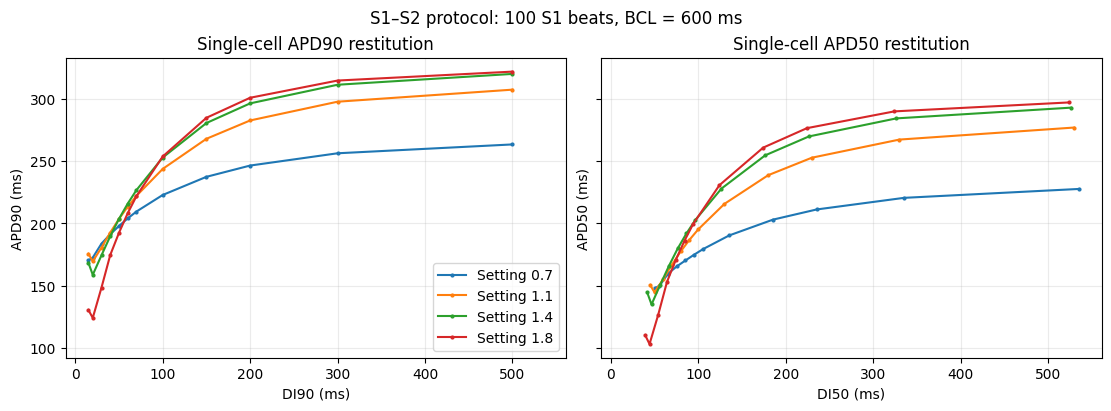

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained', 
                         sharey=True, sharex=True)
for slope, data in restitution.items():
    for ax, percent in zip(axes, (90, 50)):
        ax.plot(data[f'di{percent}'], data[f'apd{percent}'], '.-',
                markersize=4, label=f'Setting {slope}')
        ax.set(xlabel=f'DI{percent} (ms)', ylabel=f'APD{percent} (ms)',
               title=f'Single-cell APD{percent} restitution')
        ax.grid(alpha=0.25)
axes[0].legend()
fig.suptitle(f'S1–S2 protocol: {N_S1} S1 beats, BCL = {BCL:g} ms')
plt.show()

### 2.4. Inspect individual action potentials

Examine example voltage traces alongside their APD90 markers to connect the restitution measurements with the shape of each response.


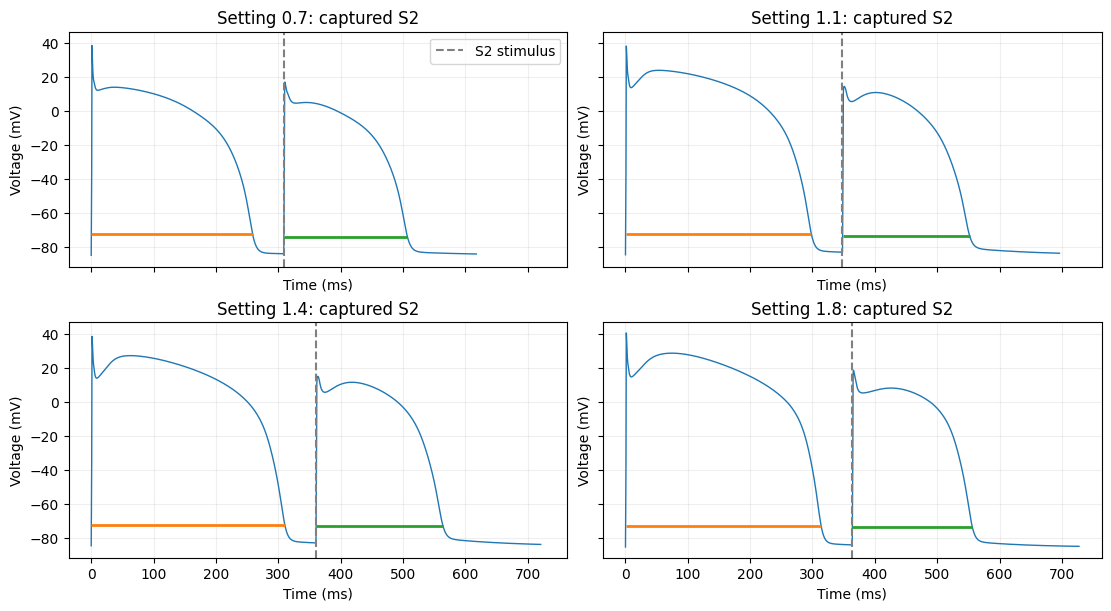

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True, layout='constrained')
for ax, (slope, (times, voltage, s1, s2_time, s2)) in zip(axes.flat, example_traces.items()):
    ax.plot(times, voltage, lw=1)
    ax.axvline(s2_time, color='0.5', ls='--', label='S2 stimulus')
    for beat, time, color in ((s1, 0.0, 'C1'), (s2, s2_time, 'C2')):
        threshold = beat['threshold90']
        activation = time + beat['repol90'] - beat['apd90']
        repolarization = time + beat['repol90']
        ax.hlines(threshold, activation, repolarization, color=color, lw=2)
    ax.set(title=f"Setting {slope}: {'captured' if s2 else 'failed/incomplete'} S2",
           xlabel='Time (ms)', ylabel='Voltage (mV)')
    ax.grid(alpha=0.2)
axes.flat[0].legend()
plt.show()

A steep restitution curve means that a small change in recovery time can produce a larger
change in the next action potential's duration. This can promote alternans, but a slope greater
than one alone does not establish instability. Pacing history, cellular recovery, and coupling
between neighboring cells also matter. Single-cell restitution therefore provides a starting
point for understanding tissue behavior, rather than a direct prediction of spiral breakup.


## 3. Spiral waves and sodium recovery

A spiral wave is a rotating excitation pattern that repeatedly activates the surrounding tissue.
Crossed S1–S2 stimulation can create a wave with a free end, around which the wavefront curls.
The resulting spiral may persist, disappear, or break into additional waves.

Recovery of the fast sodium current ($I_{Na}$) affects how readily tissue can be re-excited and how
quickly waves propagate. This section considers standard and faster, intermediate sodium
recovery. Their effects on wave rotation and the available recovery interval help explain why
the same restitution setting can behave differently in tissue.

The voltage maps and animation allow us to follow the rotating wave and look for fragmentation.
Spiral initiation and subsequent breakup are distinct events: creating a spiral does not imply
that it will become unstable.


### 3.1. Initiate a spiral wave

Apply crossed S1–S2 stimulation to a conditioned sheet of tissue and inspect the resulting excitation pattern.


Running TenTusscherPanfilov2006 on (1000, 1000) Grid:   0%|          | 0/30000 [00:00<?, ?it/s]

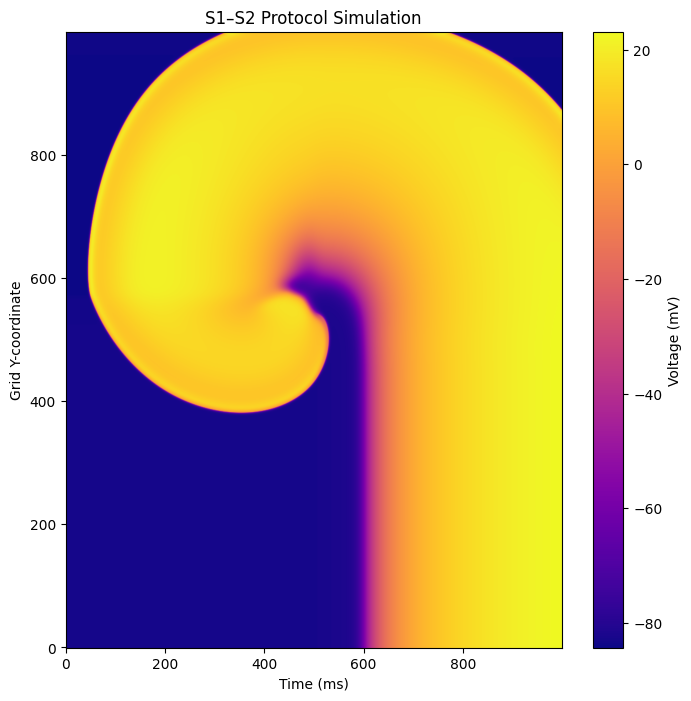

In [ ]:
import finitewave as fw
import matplotlib.pyplot as plt


GRID_SIZE = 1000

prepacing = fw.StimSingleCell(dt=0.02)
prepacing.add_stim(100, 600, 52, 1)

cardiac_model = fw.TenTusscherPanfilov2006()
cardiac_model.prepacing(prepacing)

s1_s2_protocol = fw.StimSequence()
s1_s2_protocol.add_stim(fw.StimVoltageCoord(0, 1, 0, GRID_SIZE//2, 0, GRID_SIZE))
s1_s2_protocol.add_stim(fw.StimVoltageCoord(320, 1, 0, GRID_SIZE, 0, GRID_SIZE//2))
                                
simulation = fw.CardiacSimulation(dt=0.02, t_max=600, backend="jax")
simulation.cardiac_tissue = fw.CardiacTissue((GRID_SIZE, GRID_SIZE), dr=0.25)
simulation.cardiac_model = cardiac_model
simulation.stim_sequence = s1_s2_protocol
simulation.run()

u = simulation.cardiac_model.u

plt.figure(figsize=(8, 8))
plt.imshow(u, origin='lower', aspect='auto', cmap='plasma')
plt.colorbar(label='Voltage (mV)')
plt.xlabel('Time (ms)')
plt.ylabel('Grid Y-coordinate')
plt.title('S1–S2 Protocol Simulation')
plt.show()

### 3.2. Follow the wave under altered sodium recovery

Continue from the initiated wave with a selected restitution setting and faster sodium recovery, then inspect the evolving voltage pattern.


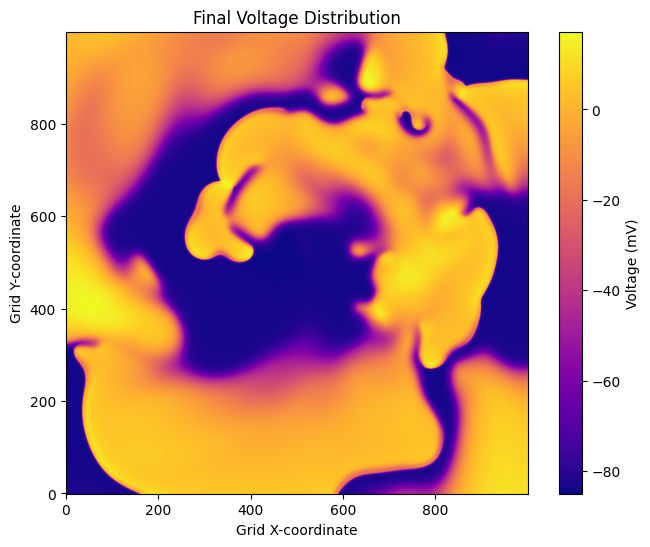

In [ ]:
import finitewave as fw

DT = 0.02                  # ms
GRID_SIZE = 1000           # grid points in each dimension


def run_simulation(model, t_max=100):
    """Run a cardiac simulation with the given model and parameters."""
    frame_tracker = fw.FrameTracker(aggregate=True, step=500)
    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(frame_tracker)

    simulation = fw.CardiacSimulation(dt=DT, t_max=t_max, backend="jax")
    simulation.cardiac_tissue = fw.CardiacTissue((GRID_SIZE, GRID_SIZE), dr=0.25)
    simulation.cardiac_model = model
    simulation.tracker_sequence = tracker_sequence
    simulation.run()

    return frame_tracker.frames[:len(frame_tracker.frames)]


state_vars_init = {}
for state_var in cardiac_model.state_vars:
    state_vars_init[state_var] = getattr(cardiac_model, f"_{state_var}")

# Use the last slope setting and a single tau_j_scale for demonstration; adjust as needed.
frames = {}
for slope in SLOPE_PARAMETERS[-1:]:
    for tau_j_scale in (0.5):
        model_x = make_tp06_model(slope)
        model_x.set_parameters({'tau_j_scale': tau_j_scale})
        model_x.set_variables(state_vars_init)
        frames_x = run_simulation(model_x, t_max=2000)
        frames[(tau_j_scale, slope)] = frames_x


im = frames_x[-1].reshape((GRID_SIZE, GRID_SIZE))

plt.figure(figsize=(8, 6))
plt.imshow(im, origin='lower', aspect='auto', cmap='plasma')
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar(label='Voltage (mV)')
plt.xlabel('Grid X-coordinate')
plt.ylabel('Grid Y-coordinate')
plt.title('Final Voltage Distribution')
plt.show()

### 3.3. Save the voltage sequence

Save the recorded tissue activity for later visualization.


In [26]:
from pathlib import Path
import numpy as np

np.save(Path("./output/alternans_frames.npy"), frames_x.reshape(-1, GRID_SIZE, GRID_SIZE).astype(np.float32))

### 3.4. Create an animation

Turn the voltage sequence into a movie so that wave rotation and possible fragmentation can be followed over time.


In [30]:
from finitewave_tools.animation import AnimationBuilder, Frame2DRenderer

output_dir = Path("./output")
animation_name = "alternans_simulation"

frames_x = np.load(output_dir / "alternans_frames.npy").astype(np.float32)

frame_renderer = Frame2DRenderer()
frame_renderer.set_frames(frames=frames_x)
frame_renderer.configure_grid(np.ones((GRID_SIZE, GRID_SIZE)))

animation = AnimationBuilder()
animation.frame_renderer = frame_renderer
animation.write(
    path=output_dir,
    animation_name=animation_name,
    fps=24,
    prog_bar=True,
    clim=(np.min(frames_x), np.max(frames_x)),
    cmap="plasma",
)

video_path = output_dir / f"{animation_name}.mp4"

Building animation: 100%|██████████| 201/201 [00:02<00:00, 70.97it/s]


### 3.5. View the wave dynamics

Play the animation and look for sustained rotation, disappearance of excitation, or the formation of additional wavefronts.


In [33]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, width=600))

## 4. Reference

Ten Tusscher, K. H. W. J., and Panfilov, A. V. (2006).
**Alternans and spiral breakup in a human ventricular tissue model.**
*American Journal of Physiology—Heart and Circulatory Physiology*, **291**(3), H1088–H1100.
[doi:10.1152/ajpheart.00109.2006](https://doi.org/10.1152/ajpheart.00109.2006)
